In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Loading data

In [17]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [18]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (1470, 35)

Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField    

Attrition count

Attrition
No     1233
Yes     237
Name: count, dtype: int64


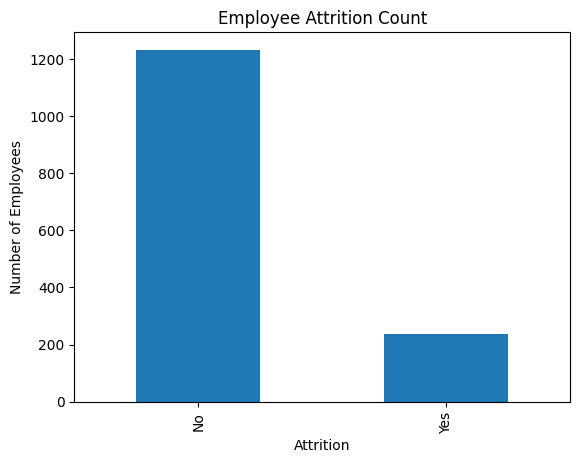

In [19]:
print(df["Attrition"].value_counts())

df["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

Encoding text columns

In [20]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Training model

In [21]:
X = df.drop(["Attrition", "EmployeeNumber", "EmployeeCount", "StandardHours"], axis=1)

y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 88.1 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294



Although the model achieved 88.10% accuracy, recall for employees who left is low due to class imbalance. Future improvement can include SMOTE, class weights, or XGBoost.

Feature importance

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

               Feature  Importance
15       MonthlyIncome    0.084692
19            OverTime    0.063224
0                  Age    0.059147
2            DailyRate    0.053481
16         MonthlyRate    0.051434
24   TotalWorkingYears    0.051000
9           HourlyRate    0.047514
4     DistanceFromHome    0.047094
27      YearsAtCompany    0.043692
17  NumCompaniesWorked    0.035327


Top 10 Important Features Chart

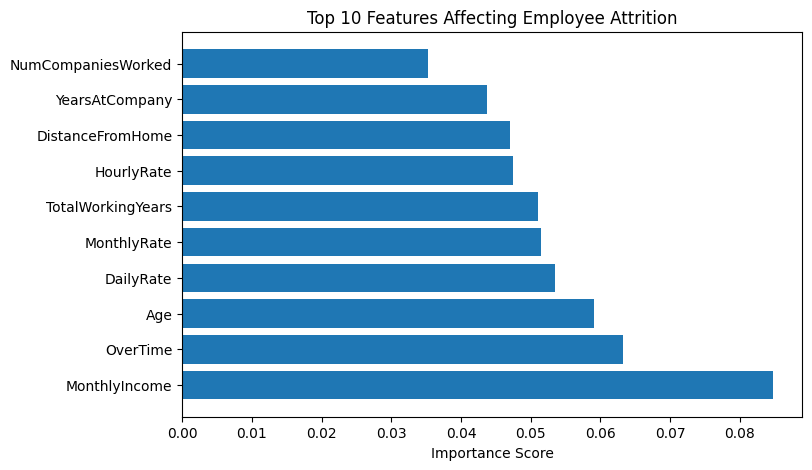

In [24]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Features Affecting Employee Attrition")
plt.xlabel("Importance Score")
plt.show()

Attrition by Overtime

Attrition    0    1
OverTime           
0          944  110
1          289  127


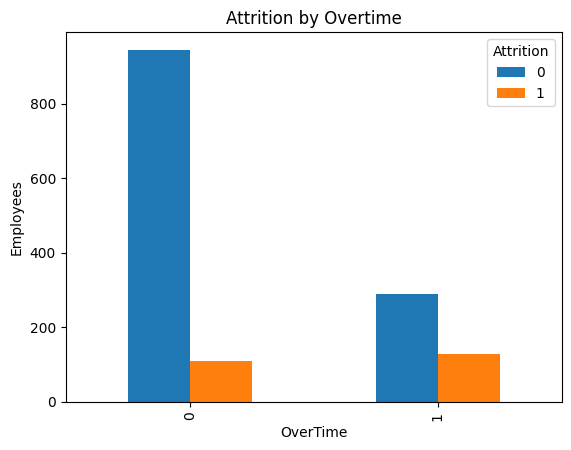

In [25]:
import pandas as pd

overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

print(overtime_attrition)

overtime_attrition.plot(kind="bar")
plt.title("Attrition by Overtime")
plt.ylabel("Employees")
plt.show()

Employees working overtime show higher attrition rates compared to employees who do not work overtime.

Attrition by Department

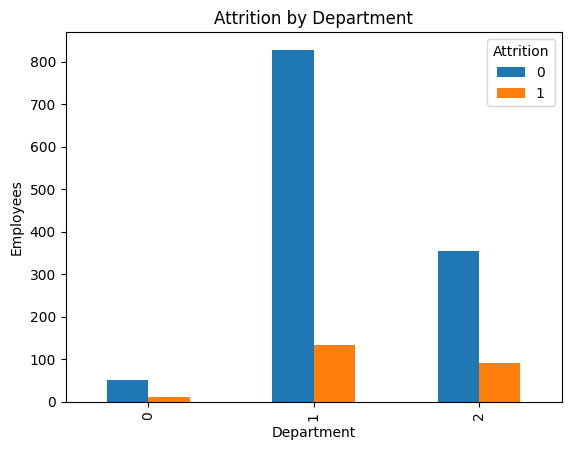

In [26]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

department_attrition.plot(kind="bar")
plt.title("Attrition by Department")
plt.ylabel("Employees")
plt.show()

Correlation Heatmap

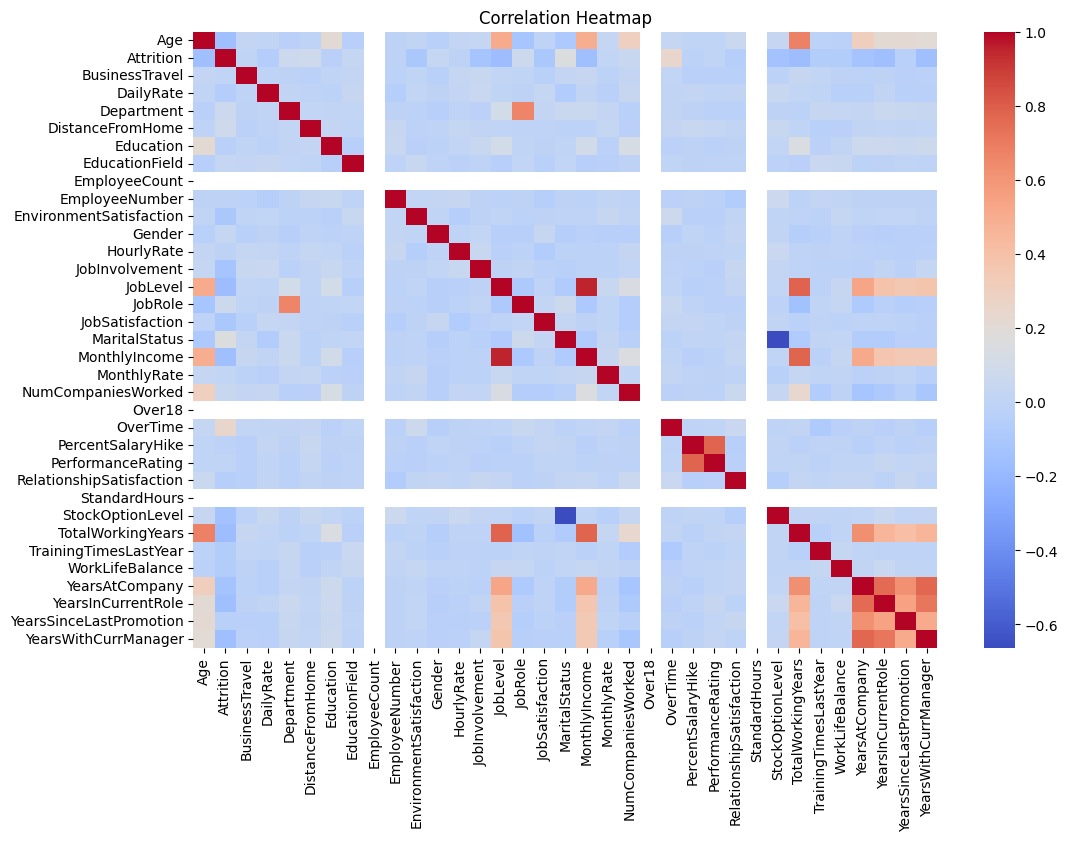

In [27]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Confusion Matrix

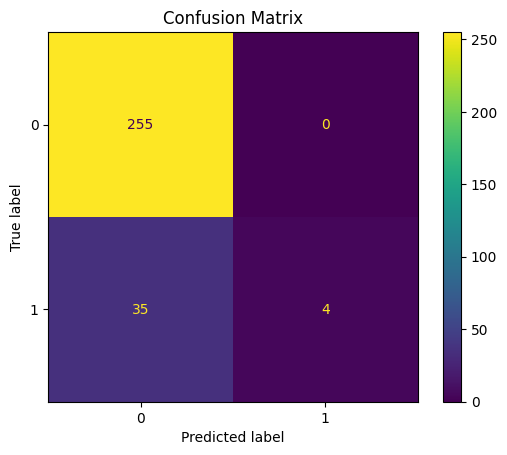

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")
plt.show()

Adding Attrition Percentage

In [29]:
attrition_rate = (
    df["Attrition"].mean()
) * 100

print(f"Employee Attrition Rate: {attrition_rate:.2f}%")

Employee Attrition Rate: 16.12%


Key Findings

1. Overtime is one of the strongest indicators of employee attrition.
2. Monthly income and age influence employee retention.
3. Certain departments experience higher attrition rates.
4. Random Forest achieved strong prediction performance.
5. Organizations can use predictive analytics to improve retention strategies.

Business Recommendations

1. Monitor employees working overtime regularly.
2. Improve employee retention programs.
3. Review compensation and monthly income structures.
4. Provide career growth opportunities for long-term employees.
5. Use predictive analytics to identify at-risk employees early.